In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [2]:
df=pd.read_csv("/Users/bhara/Downloads/Tek-Project-2/JobMarketData.csv")

In [3]:
df.head()

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,Min Experience
0,Data Scientist,2Coms,New Delhi,2 - 7 years,DataModeling\nEnterpriseApplications\nAnalytic...,838,B.Tech,Freelance,1000000-2000000,1000000,2000000,2
1,Machine Learning Engineer,2Coms,Mumbai,0-5 Yrs,Python\nComputerVision\nMachineLearning\nR\nBu...,4000,UG,Full Time,1800000-3300000,1800000,3300000,0
2,Data Scientist,2Coms Consulting Pvt Ltd.,"Chennai, Bengaluru",6-11 Yrs,Machine Learning Code DataScience R Data Model...,10000,Phd,Full Time,160000-185000,160000,185000,6
3,Machine Learning Engineer,2Coms Consulting Pvt Ltd.,"Chennai, Pune, Mumbai",3-8 Yrs,DataScience\nR\nNLP\nAlgorithms\nArtificialInt...,10000,PG/Phd,Full Time,1200000-2100000,1200000,2100000,3
4,Data Scientist,3D India Staffing Research & Consulting Co India,Bengaluru,8-13 Yrs,Team Handling\nSegmentation\nOperations Resear...,200,Phd,Full Time,5000000-1700000,5000000,1700000,8


In [4]:
df[df["Role"]=="Data Scientist"]

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,Min Experience
0,Data Scientist,2Coms,New Delhi,2 - 7 years,DataModeling\nEnterpriseApplications\nAnalytic...,838,B.Tech,Freelance,1000000-2000000,1000000,2000000,2
2,Data Scientist,2Coms Consulting Pvt Ltd.,"Chennai, Bengaluru",6-11 Yrs,Machine Learning Code DataScience R Data Model...,10000,Phd,Full Time,160000-185000,160000,185000,6
4,Data Scientist,3D India Staffing Research & Consulting Co India,Bengaluru,8-13 Yrs,Team Handling\nSegmentation\nOperations Resear...,200,Phd,Full Time,5000000-1700000,5000000,1700000,8
5,Data Scientist,3D India Staffing Research & Consulting Pvt Ltd,"Gurgaon, Gurugram",3-5 Yrs,R\nLending\nSAS\nData Scientist\nHadoop\nSpark...,200,PG,Full Time,1300000-1700000,1300000,1700000,3
6,Data Scientist,3D India Staffing Research Consulting Pvt Ltd,Gurgaon,3-5 Yrs,Quantitative Analysis\nProduct Management\nLen...,200,PG,Full Time,1500000-1900000,1500000,1900000,3
...,...,...,...,...,...,...,...,...,...,...,...,...
380,Data Scientist,Peoplefy Infosolutions Pvt. Ltd,Pune,0-4 Yrs,MachineLearning\nDeepLearning\nPython,200,PG/PhD,Full Time,500000-700000,500000,700000,0
381,Data Scientist,Louis Dreyfus Commodities,Bengaluru,0-3 Yrs,Python\nSQL,17000,MS Stats,Full TIme,NaN,#VALUE!,#VALUE!,0
385,Data Scientist,Simulation Hub,Pune,1-3 Yrs,DataVisualization\nInformationTechnology\nAnal...,200,UG,Full Time,800000-1000000,800000,1000000,1
386,Data Scientist,NEEMTREE INTERNET PVT LTD,Gurgaon,4-8 Yrs,BusinessIntelligence\nAnalytics\nPython,50,UG,Full Time,NaN,#VALUE!,#VALUE!,4


In [5]:
df.columns

Index(['Role', 'Companies', 'Location', 'Experience', 'Skills', 'Company Size',
       'Eligibility Criteria', 'Enrollment Type', 'Salary', 'Min Salary',
       'Max Salary', 'Min Experience'],
      dtype='object')

In [6]:
df["Role"].unique()

array(['Data Scientist', 'Machine Learning Engineer', 'Data Engineer',
       'Applied Scientist (Machine Learning)', 'For Data Scientist',
       'Data Analyst', 'Elastic Path Solutions Application Developer',
       'Machine Learning Data Science Practitioner',
       'SAP BusinessObjects Data Services Application Developer',
       'Artificial Intelligence Scientist',
       'Trainee-freshers-machine Learning-ai-data Scientist',
       'ML/AI Intern', 'Python Developer', 'Applied Scientist - Intern',
       'Software Engineer', 'Senior Decision Scientist',
       'AWS Engineer(AWS glue)', 'Machine Learning/NLP Expert',
       'Cloud Migration Consultant', 'COE Lead- Artificial Intelligence',
       'Technical Architect', 'Artificial Intelligence Architect',
       'Test Specialist:Middleware', 'Teradata Administrator',
       'Machine Learning Architect', 'Engineer,Product Applications',
       'Tibco Spotfire Developer', 'Systems Integration Specialist',
       'Technical Project L

In [7]:
df["Skills"].unique()

array(['DataModeling\\nEnterpriseApplications\\nAnalyticalConsultingMachineLearning',
       'Python\\nComputerVision\\nMachineLearning\\nR\\nBusinessAnalysis',
       'Machine Learning Code DataScience R Data Model NLPAlgorithms Coding',
       'DataScience\\nR\\nNLP\\nAlgorithms\\nArtificialIntelligence\\nImageProcessing\\nNaturalLanguageProcessing\\nMachineLearning',
       'Team Handling\\nSegmentation\\nOperations Research\\nData Mining\\nMachine Learning\\nStatistics\\nAnalytics\\nClementine',
       'R\\nLending\\nSAS\\nData Scientist\\nHadoop\\nSpark\\nIIM\\nAnalytics',
       'Quantitative Analysis\\nProduct Management\\nLending\\nIIM\\nStatistical Analysis\\nMachine Learning\\nCredit Risk Analysis\\nAnalytics',
       'R\\nLending\\nSAS\\nHadoop\\nSpark\\nIIM\\nquantitative analysis\\nMachine Learning',
       'Data Science\\nJava\\nR\\nArtificial Intelligence\\nData Scientist\\nSCALA\\nData Mining\\nData Visualization',
       'Java\\nBusiness Intelligence\\nR\\nETL Tools\\n

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Role                  388 non-null    object
 1   Companies             388 non-null    object
 2   Location              388 non-null    object
 3   Experience            388 non-null    object
 4   Skills                388 non-null    object
 5   Company Size          373 non-null    object
 6   Eligibility Criteria  388 non-null    object
 7   Enrollment Type       388 non-null    object
 8   Salary                326 non-null    object
 9   Min Salary            388 non-null    object
 10  Max Salary            388 non-null    object
 11  Min Experience        388 non-null    object
dtypes: object(12)
memory usage: 36.5+ KB


In [9]:
df.shape

(388, 12)

In [10]:
df.isnull().sum()

Role                     0
Companies                0
Location                 0
Experience               0
Skills                   0
Company Size            15
Eligibility Criteria     0
Enrollment Type          0
Salary                  62
Min Salary               0
Max Salary               0
Min Experience           0
dtype: int64

In [11]:
df.drop('Min Experience',inplace=True, axis=1)

In [12]:
df.isnull().sum()

Role                     0
Companies                0
Location                 0
Experience               0
Skills                   0
Company Size            15
Eligibility Criteria     0
Enrollment Type          0
Salary                  62
Min Salary               0
Max Salary               0
dtype: int64

In [13]:
df.head(5)

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary
0,Data Scientist,2Coms,New Delhi,2 - 7 years,DataModeling\nEnterpriseApplications\nAnalytic...,838,B.Tech,Freelance,1000000-2000000,1000000,2000000
1,Machine Learning Engineer,2Coms,Mumbai,0-5 Yrs,Python\nComputerVision\nMachineLearning\nR\nBu...,4000,UG,Full Time,1800000-3300000,1800000,3300000
2,Data Scientist,2Coms Consulting Pvt Ltd.,"Chennai, Bengaluru",6-11 Yrs,Machine Learning Code DataScience R Data Model...,10000,Phd,Full Time,160000-185000,160000,185000
3,Machine Learning Engineer,2Coms Consulting Pvt Ltd.,"Chennai, Pune, Mumbai",3-8 Yrs,DataScience\nR\nNLP\nAlgorithms\nArtificialInt...,10000,PG/Phd,Full Time,1200000-2100000,1200000,2100000
4,Data Scientist,3D India Staffing Research & Consulting Co India,Bengaluru,8-13 Yrs,Team Handling\nSegmentation\nOperations Resear...,200,Phd,Full Time,5000000-1700000,5000000,1700000


In [14]:
df['Company Size'].fillna('0',inplace=True)
df['Salary'].fillna('0',inplace=True)
df.replace(['#VALUE!'],['0'],inplace=True)

C:\Users\bhara\AppData\Local\Temp\ipykernel_10868\1869144103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Company Size'].fillna('0',inplace=True)
C:\Users\bhara\AppData\Local\Temp\ipykernel_10868\1869144103.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [15]:
df['Max Salary'] = df['Max Salary'].astype(str)
df['Min Salary'] = df['Min Salary'].astype(str)

df['Max Salary'] = df['Max Salary'].str.replace(',', '').str.replace(' ', '').astype('int64')
df['Min Salary'] = df['Min Salary'].str.replace(',', '').str.replace(' ', '').astype('int64')


In [16]:
experience_split = df['Experience'].str[0:-3].str.split('-', expand=True)
experience_split.head()

,0,1
0,2,7 ye
1,0,5
2,6,11
3,3,8
4,8,13


In [17]:
#remove space in left and right
experience_split[0] =  experience_split[0].str.strip()
#remove comma
experience_split[0] = experience_split[0].str.replace('Yr', '')

#remove all character in two condition
# 1 remove if only character
# 2 if start in number remove after all character
experience_split[0] = experience_split[0].str.replace(r'Yr', '')
#display
experience_split[0].head()

0    2
1    0
2    6
3    3
4    8
Name: 0, dtype: object

In [18]:
#remove space in left and right
experience_split[1] =  experience_split[1].str.strip()
#remove comma
experience_split[1] = experience_split[1].str.replace('Yr', '')

#remove all character in two condition
# 1 remove if only character
# 2 if start in number remove after all character
experience_split[1] = experience_split[1].str.replace(r'Yr', '')
#display
experience_split[1].head()


0    7 ye
1       5
2      11
3       8
4      13
Name: 1, dtype: object

In [19]:
experience_split[0] = pd.to_numeric(experience_split[0], errors='coerce')
experience_split[1] = pd.to_numeric(experience_split[1], errors='coerce')

In [20]:
experience=pd.concat([experience_split[0], experience_split[1]], axis=1, sort=False)

In [21]:
experience.rename(columns={0:'min_experience', 1:'max_experience'}, inplace=True)
experience.head()

,min_experience,max_experience
0,2.0,NaN
1,0.0,5.0
2,6.0,11.0
3,3.0,8.0
4,8.0,13.0


In [22]:
df['min_experience']=experience_split[0]
df['max_experience']=experience_split[1]
df['avg_pay']=(df['Min Salary'].values + df['Max Salary'].values)/2
df['avg_experience']=(df['min_experience'].values + df['max_experience'].values)/2
df.head(3)

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,min_experience,max_experience,avg_pay,avg_experience
0,Data Scientist,2Coms,New Delhi,2 - 7 years,DataModeling\nEnterpriseApplications\nAnalytic...,838,B.Tech,Freelance,1000000-2000000,1000000,2000000,2.0,NaN,1500000.0,NaN
1,Machine Learning Engineer,2Coms,Mumbai,0-5 Yrs,Python\nComputerVision\nMachineLearning\nR\nBu...,4000,UG,Full Time,1800000-3300000,1800000,3300000,0.0,5.0,2550000.0,2.5
2,Data Scientist,2Coms Consulting Pvt Ltd.,"Chennai, Bengaluru",6-11 Yrs,Machine Learning Code DataScience R Data Model...,10000,Phd,Full Time,160000-185000,160000,185000,6.0,11.0,172500.0,8.5


<Axes: xlabel='min_experience', ylabel='Min Salary'>

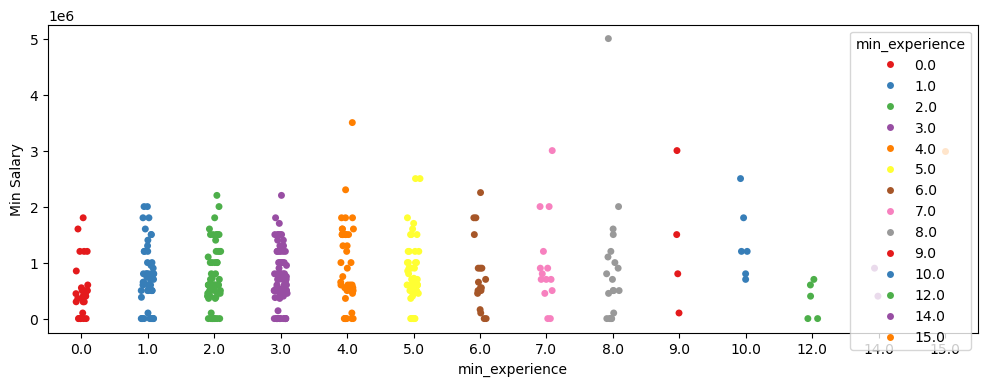

In [23]:
f,ax=plt.subplots(figsize=(12,4))

sns.stripplot(x='min_experience',y='Min Salary',data=df,jitter=True,hue="min_experience",palette="Set1")

<Axes: xlabel='min_experience', ylabel='Min Salary'>

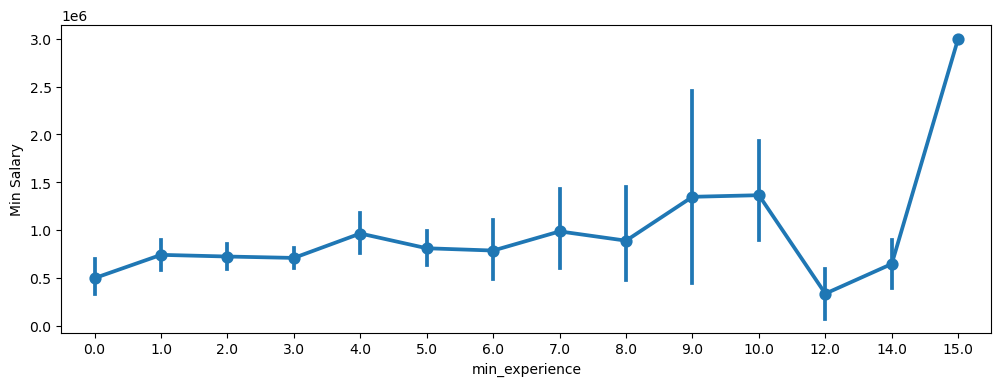

In [24]:
f,ax=plt.subplots(figsize=(12,4))
sns.pointplot(x='min_experience', y='Min Salary', data=df)

<Axes: xlabel='max_experience', ylabel='Max Salary'>

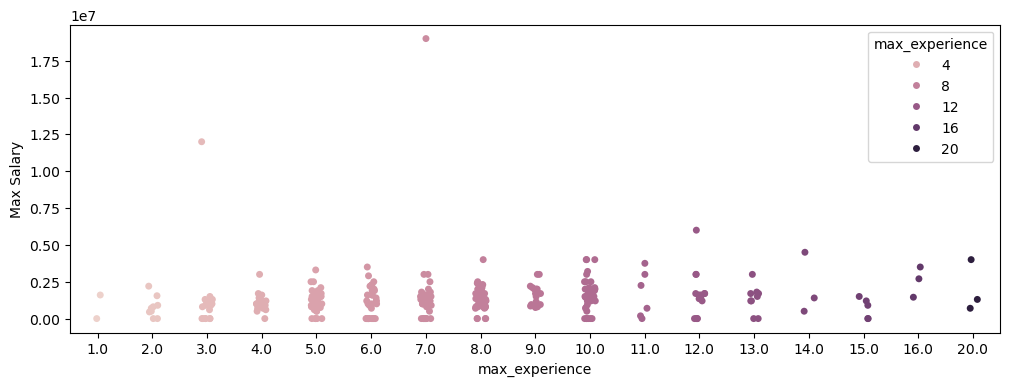

In [25]:
f,ax=plt.subplots(figsize=(12,4))
sns.stripplot(x='max_experience', y='Max Salary', data=df, jitter=True,hue="max_experience")

<Axes: xlabel='max_experience', ylabel='Max Salary'>

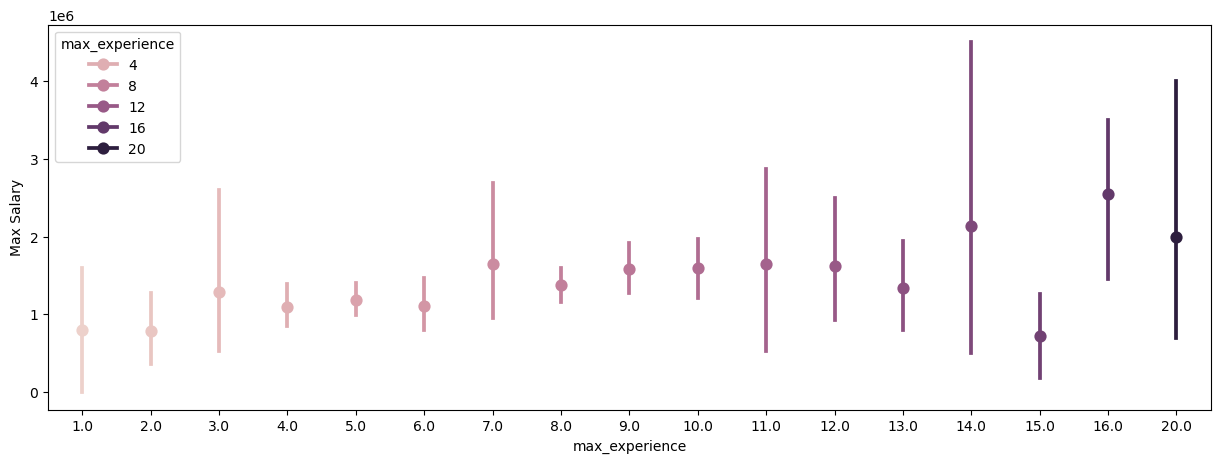

In [26]:
f,ax=plt.subplots(figsize=(15,5))
sns.pointplot(x='max_experience', y='Max Salary', data=df,hue="max_experience")

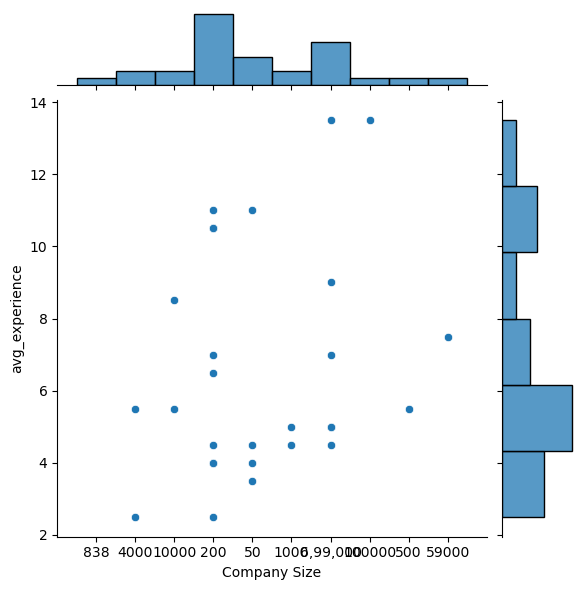

In [29]:
sns.jointplot(x= 'Company Size',y= 'avg_experience', data =df.head(30))

In [30]:
from wordcloud import WordCloud
from matplotlib import colors

color_list=  ['DarkBlue','Teal','LightBlue','MediumAquamarine','Plum','OrangeRed','DarkRed','Pink','LightGoldenrodYellow']

colormap = colors.ListedColormap(color_list)

plt.rcParams['figure.figsize'] = (15,15)

wordcloud =  WordCloud(background_color= 'white',
                       width = 1200,height = 800 ,
                       max_words = 120,colormap = colormap ).generate(" ".join(df['Role']))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [31]:
df3= df[["Location","Role"]].groupby("Location").count().sort_values("Role",ascending=False)
df3

,Role
Location,
Bengaluru,98
Chennai,58
Hyderabad,28
Gurgaon,20
Mumbai,20
...,...
"Kolkata, Hyderabad, Chennai, Pune",1
Mohali SAS Nagar,1
"Mohali,New Delhi,Chandigarh",1


In [32]:
df3=df3.sort_values("Role",ascending = False).head(6)

In [33]:
df3

,Role
Location,
Bengaluru,98
Chennai,58
Hyderabad,28
Gurgaon,20
Mumbai,20
Noida,20


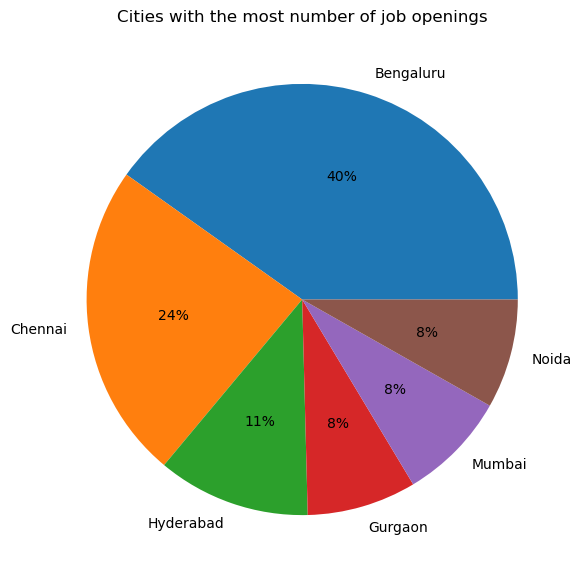

In [34]:
plt.figure(figsize=(10,7))
plt.title('Cities with the most number of job openings')
plt.pie(x=df3.Role,labels=df3.index,autopct='%1.0f%%')
plt.show()


In [35]:
df4= df[["Companies","Role"]].groupby("Companies").count()

In [36]:
df4

,Role
Companies,
2Coms,2
2Coms Consulting Pvt Ltd.,2
3D India Staffing Research & Consulting Co India,1
3D India Staffing Research & Consulting Pvt Ltd,1
3D India Staffing Research Consulting Pvt Ltd,4
...,...
YALLAS TECHNOLOGY SOLUTIONS (OPC) Pvt Ltd,1
Zoho,1
iKomet Technology Solutions,1


In [37]:
df4=df4.sort_values("Role",ascending = False).head(10)
df4

,Role
Companies,
Analytics Vidhya Educon Pvt. Ltd,24
Accenture,6
Wipro,6
Walmart,5
IBM,4
3D India Staffing Research Consulting Pvt Ltd,4
AgNext Technologies ( India's leading Agri Tech driven Company),3
Tech Mahindra,3
AICHUNKS Private Limited,3


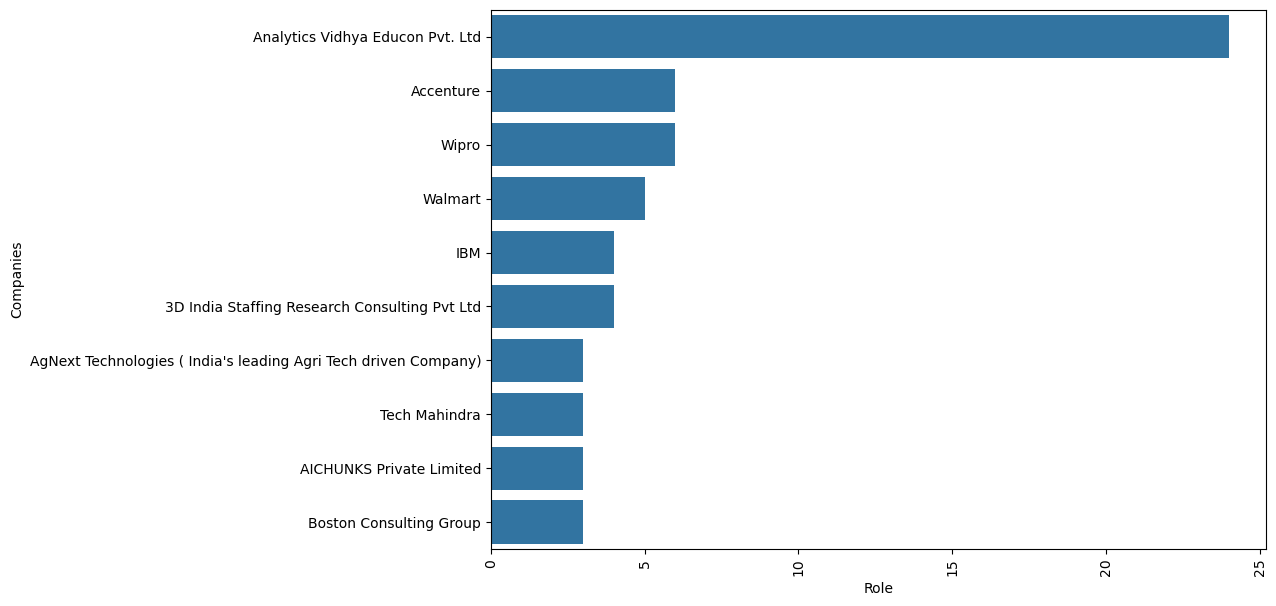

In [38]:
plt.figure(figsize=(10,7))
sns.barplot(y=df4.index,x=df4.Role)
plt.xticks(rotation=90)
plt.show()

In [39]:
a=df[df.Companies=='Analytics Vidhya Educon Pvt. Ltd']
a.Location.value_counts()

Location
Bengaluru    12
Noida         3
Mumbai        3
Pune          3
Chennai       2
Hyderabad     1
Name: count, dtype: int64

In [40]:
df5= df[["Role","Experience"]].groupby("Experience").count()
df5 = df5.sort_values("Role",ascending = False).head(7)
df5

,Role
Experience,
3-8 Yrs,29
5-10 Yrs,23
2-7 Yrs,22
3-6 Yrs,12
2-5 Yrs,12
4-9 Yrs,12
4-8 Yrs,11


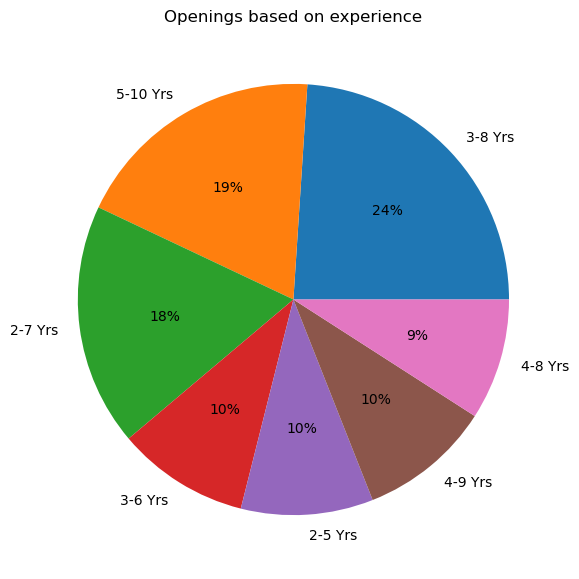

In [41]:
plt.figure(figsize=(10,7))
plt.title('Openings based on experience')
plt.pie(x=df5.Role,labels=df5.index,autopct='%1.0f%%')
plt.show()


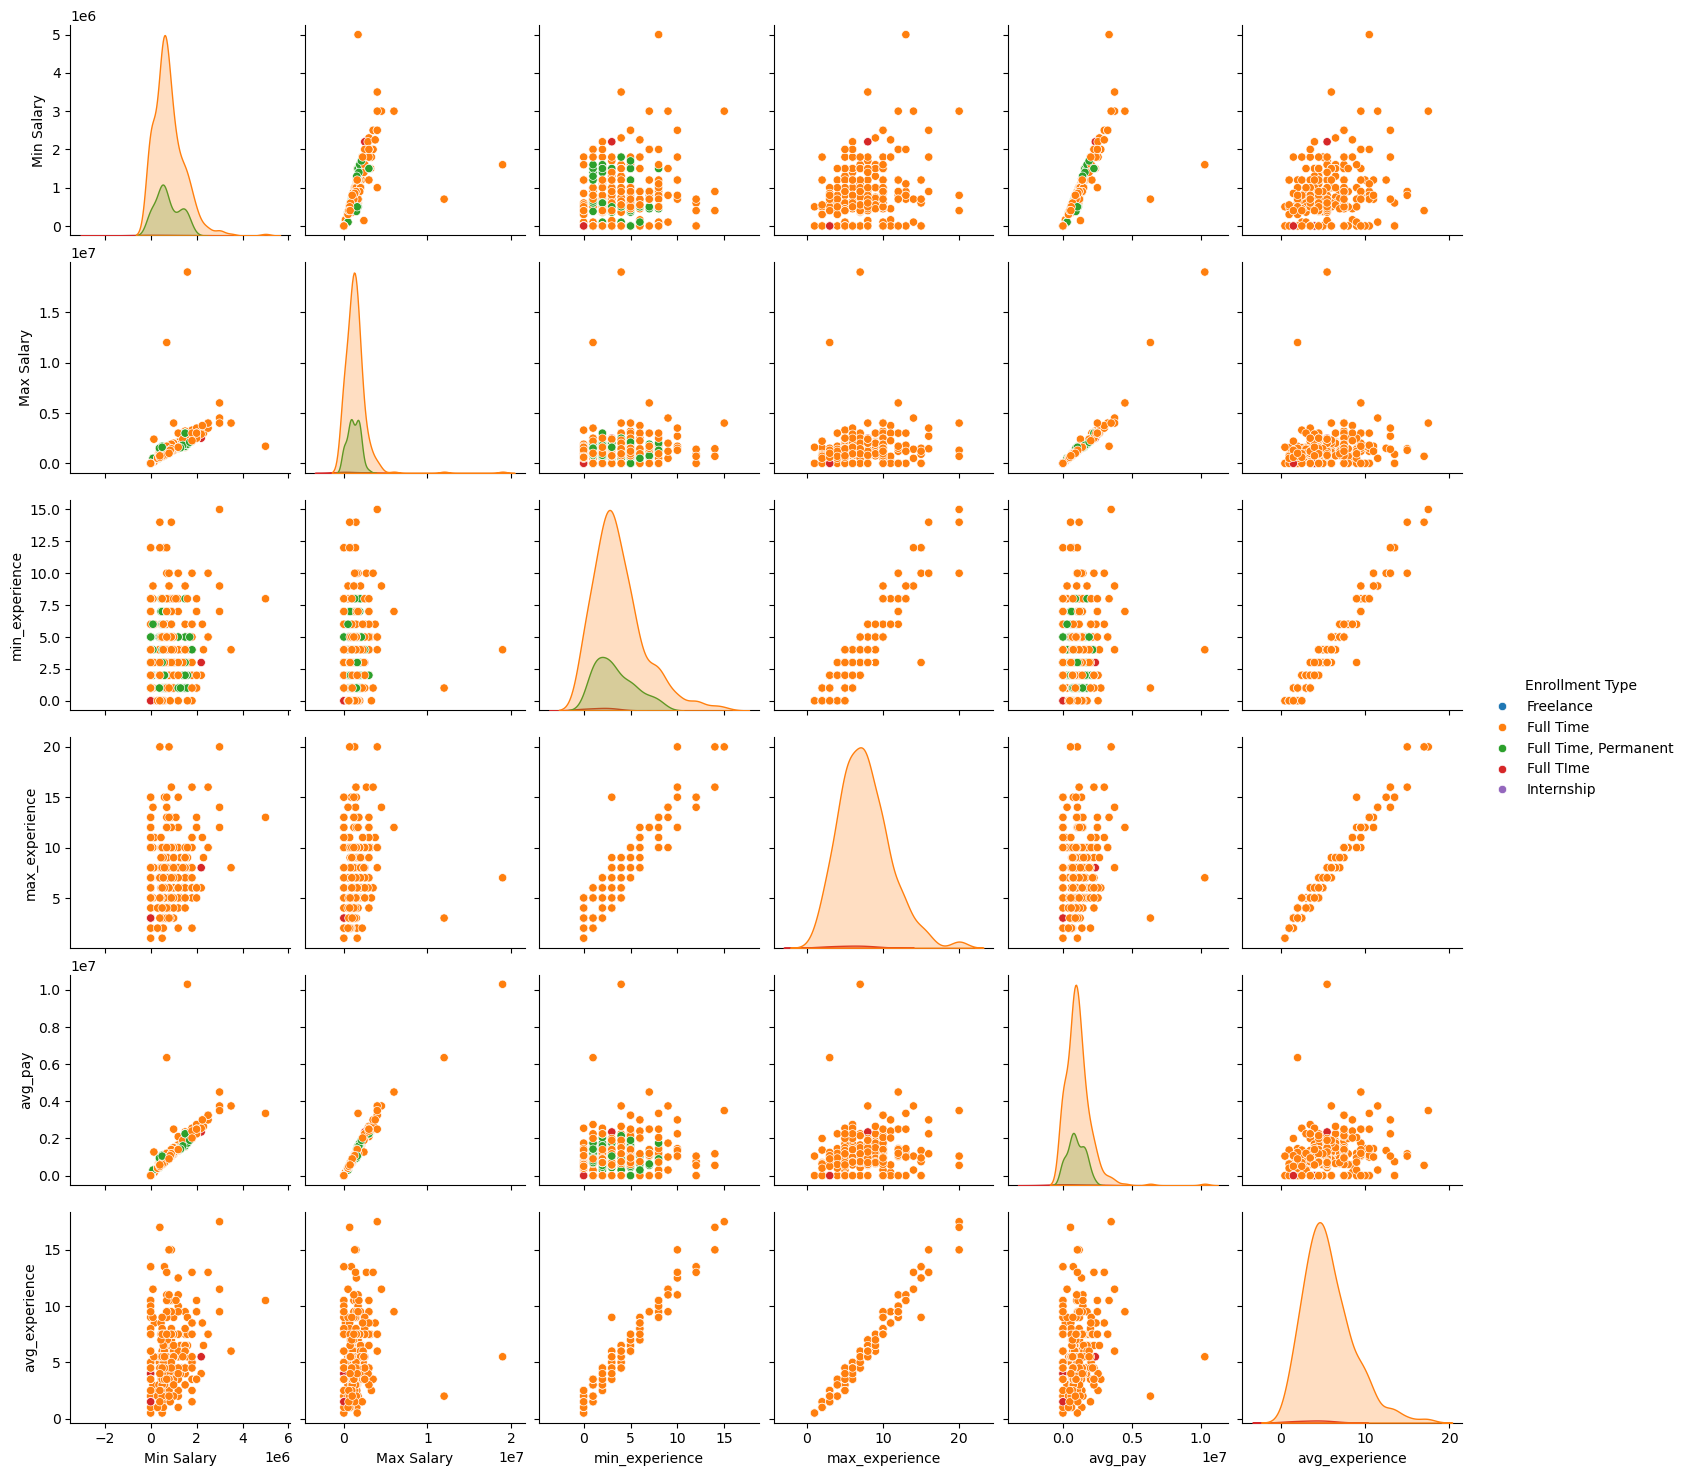

In [42]:
sns.pairplot(df,hue='Enrollment Type')

In [43]:
data1 = df.copy()
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Role                  388 non-null    object 
 1   Companies             388 non-null    object 
 2   Location              388 non-null    object 
 3   Experience            388 non-null    object 
 4   Skills                388 non-null    object 
 5   Company Size          388 non-null    object 
 6   Eligibility Criteria  388 non-null    object 
 7   Enrollment Type       388 non-null    object 
 8   Salary                388 non-null    object 
 9   Min Salary            388 non-null    int64  
 10  Max Salary            388 non-null    int64  
 11  min_experience        386 non-null    float64
 12  max_experience        303 non-null    float64
 13  avg_pay               388 non-null    float64
 14  avg_experience        303 non-null    float64
dtypes: float64(4), int64(2)

In [44]:
from sklearn.preprocessing import LabelEncoder
labelencoder_X = LabelEncoder()
for i in data1.columns:
    data1[i] = labelencoder_X.fit_transform(data1[i])
data1.head()

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,min_experience,max_experience,avg_pay,avg_experience
0,12,0,60,32,103,115,3,0,6,22,29,2,17,48,29
1,23,0,47,8,245,82,18,2,49,30,40,0,4,67,4
2,12,1,8,83,179,9,17,2,35,3,1,6,10,1,16
3,23,1,10,56,128,9,16,2,15,24,30,3,7,52,10
4,12,2,1,98,339,44,17,2,93,38,25,8,12,72,20


In [48]:
data1.describe()

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,min_experience,max_experience,avg_pay,avg_experience
count,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000
mean,15.391753,141.494845,26.654639,48.989691,185.461340,57.164948,14.878866,2.188144,59.997423,14.940722,16.827320,3.659794,8.811856,28.556701,14.301546
std,6.506696,90.756297,26.469607,26.626324,106.730776,33.881136,7.170372,0.435105,47.695551,10.046357,12.083627,2.651650,5.190745,21.437232,9.251820
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,51.750000,1.000000,30.750000,95.750000,32.000000,14.000000,2.000000,12.000000,8.000000,7.000000,2.000000,5.000000,12.000000,7.000000
50%,12.000000,136.500000,18.000000,51.000000,184.500000,49.000000,18.000000,2.000000,61.500000,13.000000,16.000000,3.000000,7.000000,26.000000,11.000000
75%,23.000000,220.250000,47.000000,69.000000,277.250000,92.000000,20.000000,2.000000,104.000000,24.000000,25.000000,5.000000,13.000000,47.000000,22.000000
max,38.000000,299.000000,83.000000,101.000000,371.000000,116.000000,21.000000,4.000000,144.000000,38.000000,47.000000,14.000000,17.000000,77.000000,29.000000


In [49]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Role                  388 non-null    int32
 1   Companies             388 non-null    int32
 2   Location              388 non-null    int32
 3   Experience            388 non-null    int32
 4   Skills                388 non-null    int32
 5   Company Size          388 non-null    int32
 6   Eligibility Criteria  388 non-null    int32
 7   Enrollment Type       388 non-null    int32
 8   Salary                388 non-null    int32
 9   Min Salary            388 non-null    int64
 10  Max Salary            388 non-null    int64
 11  min_experience        388 non-null    int64
 12  max_experience        388 non-null    int64
 13  avg_pay               388 non-null    int64
 14  avg_experience        388 non-null    int64
dtypes: int32(9), int64(6)
memory usage: 32.0 KB


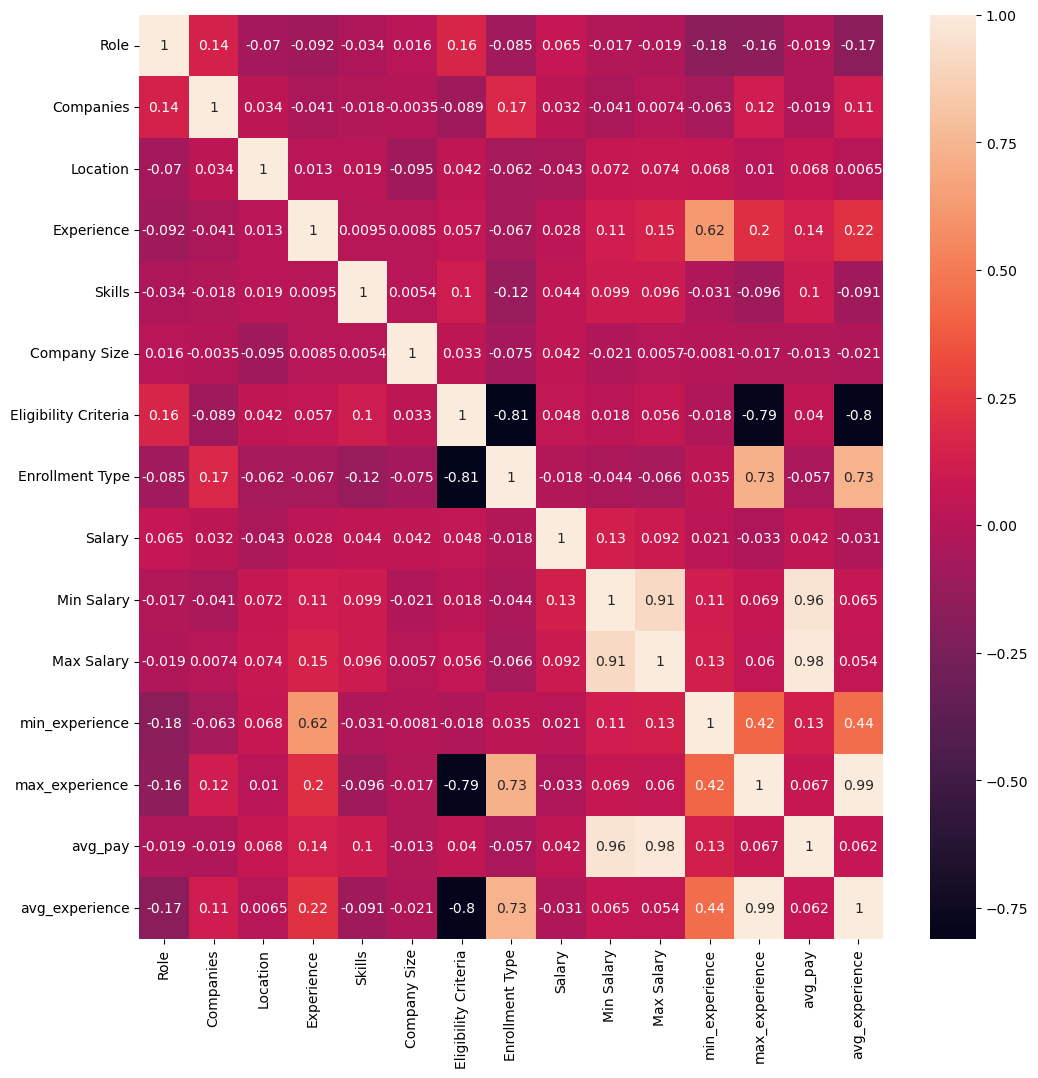

In [50]:
plt.figure(figsize=(12,12))
sns.heatmap(data1.corr(), annot=True)
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler
features = ['Role','Companies','Location','Experience','Skills','Company Size','Eligibility Criteria','Enrollment Type','Salary','Min Salary','Max Salary','min_experience', 'max_experience']
# Separating out the features
x = data1.loc[:, features].values
x = StandardScaler().fit_transform(x)

In [52]:
x

array([[-0.52194416, -1.56107667,  1.26138686, ...,  1.00867046,
        -0.62675575,  1.5794873 ],
       [ 1.17080484, -1.56107667,  0.76962343, ...,  1.92016856,
        -1.38197697, -0.92820358],
       [-0.52194416, -1.55004392, -0.70566688, ..., -1.31150652,
         0.88368668,  0.22919221],
       ...,
       [-0.52194416,  1.19710979,  1.71532234, ..., -0.31714496,
        -1.00436636, -1.31400218],
       [-0.52194416,  0.53514504, -0.32738732, ..., -1.39436999,
         0.12846546, -0.34950569],
       [-0.52194416, -0.2702454 , -0.40304323, ..., -0.73146228,
        -0.24914514, -0.92820358]])

In [53]:
from sklearn.decomposition import PCA
pca = PCA(n_components=13)
t = pca.fit_transform(x)
data2 = pd.DataFrame(t, columns=['PC1', 'PC2','PC3','PC4','Pc5','PC6', 'PC7','PC8','PC9','PC10','PC11','PC12','PC13'])
data2

,PC1,PC2,PC3,PC4,Pc5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-1.057532,1.254945,0.186153,-1.367949,-1.402352,1.502712,-1.973416,1.263920,0.944325,0.459969,5.143641,0.151705,0.349618
1,-1.813528,1.176342,-2.537075,-0.880080,-0.988059,0.649324,-0.484909,0.258431,1.730680,0.128081,-0.173078,0.087887,0.368222
2,0.050773,-0.539671,2.658435,-0.691277,-0.334962,0.207976,1.529378,-0.913534,0.215509,-0.200928,0.214850,0.215852,-0.107082
3,-0.669565,0.989210,-0.467042,-0.702786,-0.070996,1.745084,1.270939,-1.380567,0.997197,-0.262121,0.189532,0.004509,0.205581
4,0.386334,3.375219,1.034714,0.213496,-1.338701,-0.699253,1.211016,-0.962216,0.430955,-0.005930,0.135349,-0.149201,-1.099277
...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,-1.856185,-2.066623,-1.381226,1.187674,-0.321904,-1.115864,-0.813752,-0.399698,-0.602900,0.336978,-0.039073,-0.366375,-0.150395
384,-1.384013,-1.937458,-0.719356,0.569152,-1.353172,-0.372458,-0.853974,0.627462,-1.272027,0.216057,0.013445,-0.000460,-0.241650
385,-1.375850,-0.502512,-1.319245,-0.610234,1.294570,-0.648035,0.156836,2.140075,-0.941632,0.034586,-0.110758,-0.480462,-0.311775
386,-0.338760,-1.663011,1.891232,0.448279,0.105480,1.237230,-1.243436,0.129463,-0.899899,-0.313515,0.009760,0.022289,-0.062930


In [54]:
df_13=df.iloc[:,:13]
df_13.head(3)

,Role,Companies,Location,Experience,Skills,Company Size,Eligibility Criteria,Enrollment Type,Salary,Min Salary,Max Salary,min_experience,max_experience
0,Data Scientist,2Coms,New Delhi,2 - 7 years,DataModeling\nEnterpriseApplications\nAnalytic...,838,B.Tech,Freelance,1000000-2000000,1000000,2000000,2.0,NaN
1,Machine Learning Engineer,2Coms,Mumbai,0-5 Yrs,Python\nComputerVision\nMachineLearning\nR\nBu...,4000,UG,Full Time,1800000-3300000,1800000,3300000,0.0,5.0
2,Data Scientist,2Coms Consulting Pvt Ltd.,"Chennai, Bengaluru",6-11 Yrs,Machine Learning Code DataScience R Data Model...,10000,Phd,Full Time,160000-185000,160000,185000,6.0,11.0


In [55]:
# correlation coefficient between original variables and the component

loadings = pca.components_
#Use n_features_in_ instead of n_features_
num_pc = pca.n_features_in_
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))
loadings_df['variable'] = df_13.columns.values
loadings_df = loadings_df.set_index('variable')
loadings_df


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
variable,,,,,,,,,,,,,
Role,-0.153090,-0.089854,-0.231597,0.454967,0.378343,0.163368,0.055621,-0.267844,0.676106,0.054346,0.031742,-0.040986,0.020776
Companies,0.095204,-0.081754,-0.219165,0.313426,0.579425,-0.217413,-0.342536,-0.100022,-0.565862,0.031304,0.046715,-0.059000,-0.028335
Location,-0.007483,0.110732,0.031610,-0.468628,0.489212,-0.155618,-0.292857,0.538023,0.347584,-0.080064,-0.031394,-0.008633,0.002582
Experience,0.115748,0.351852,0.508023,0.224217,0.139766,-0.015614,0.014665,-0.148615,0.021971,-0.713705,0.001360,0.030777,-0.039443
Skills,-0.102981,0.125109,-0.069579,-0.122530,-0.177769,-0.840809,-0.111438,-0.400519,0.203241,0.027300,-0.019272,-0.006148,0.005458
Company Size,-0.042383,0.000992,0.025618,0.432405,-0.442765,0.015718,-0.706809,0.304609,0.134281,-0.013051,-0.055694,-0.017349,-0.017701
Eligibility Criteria,-0.540003,0.136728,0.175370,0.054533,0.117583,0.031301,-0.007845,-0.016572,-0.111218,0.180400,-0.434636,0.605397,-0.201258
Enrollment Type,0.525430,-0.154794,-0.192536,0.012396,-0.019663,-0.033835,0.053033,-0.017987,0.081586,-0.118658,-0.797209,0.033411,-0.026004
Salary,-0.032161,0.122155,-0.129679,0.441871,-0.030125,-0.384129,0.522548,0.589407,-0.033029,-0.009663,0.029692,0.017034,0.026477


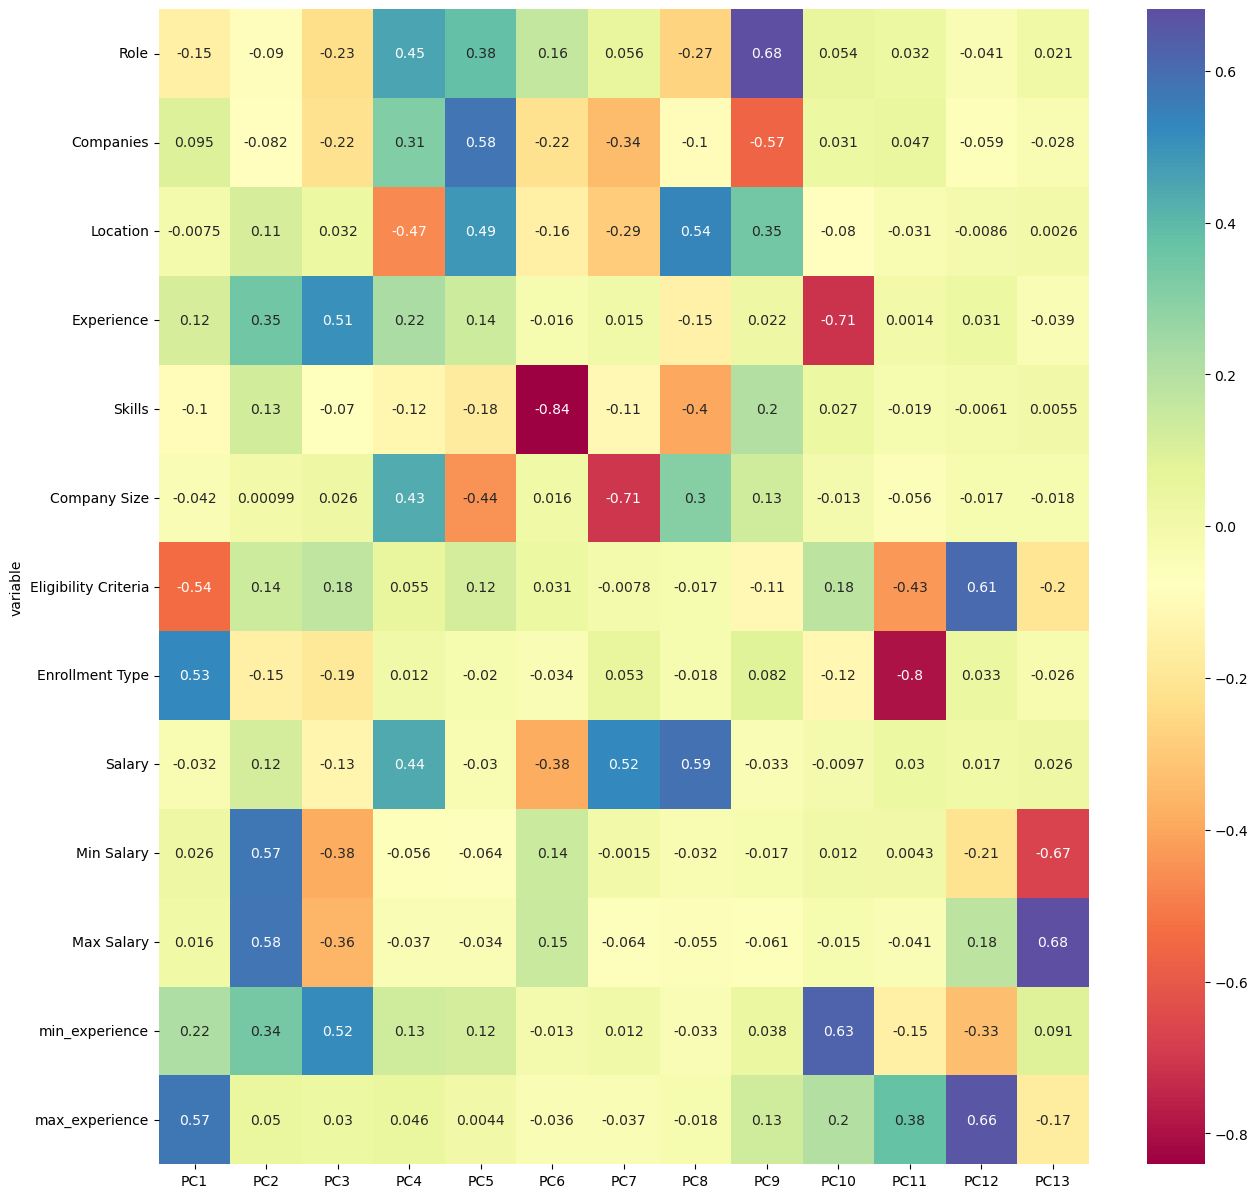

In [56]:
#Correlation matrix plot for loadings
plt.rcParams['figure.figsize'] = (15,15)
ax = sns.heatmap(loadings_df, annot=True, cmap='Spectral')
plt.show()

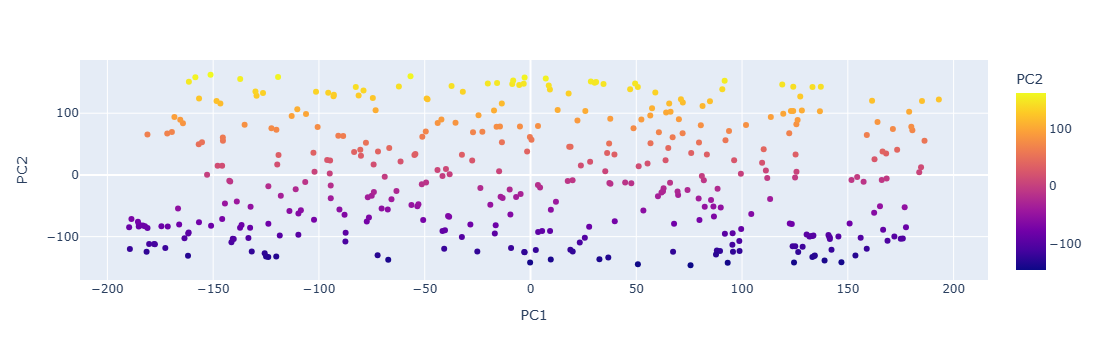

In [57]:
import plotly.express as px
features2 = ['Role','Companies','Location','Experience','Skills','Company Size','Eligibility Criteria','Enrollment Type','Salary','Min Salary','Max Salary','min_experience', 'max_experience' ]
y1 = data1.loc[:, features2].values
pca2 = PCA(n_components=2)
components = pca2.fit_transform(y1)
fig = px.scatter(components, x=0, y=1, color=1,labels={'0': 'PC1', '1': 'PC2'})
fig.show()

<Axes: xlabel='Role'>

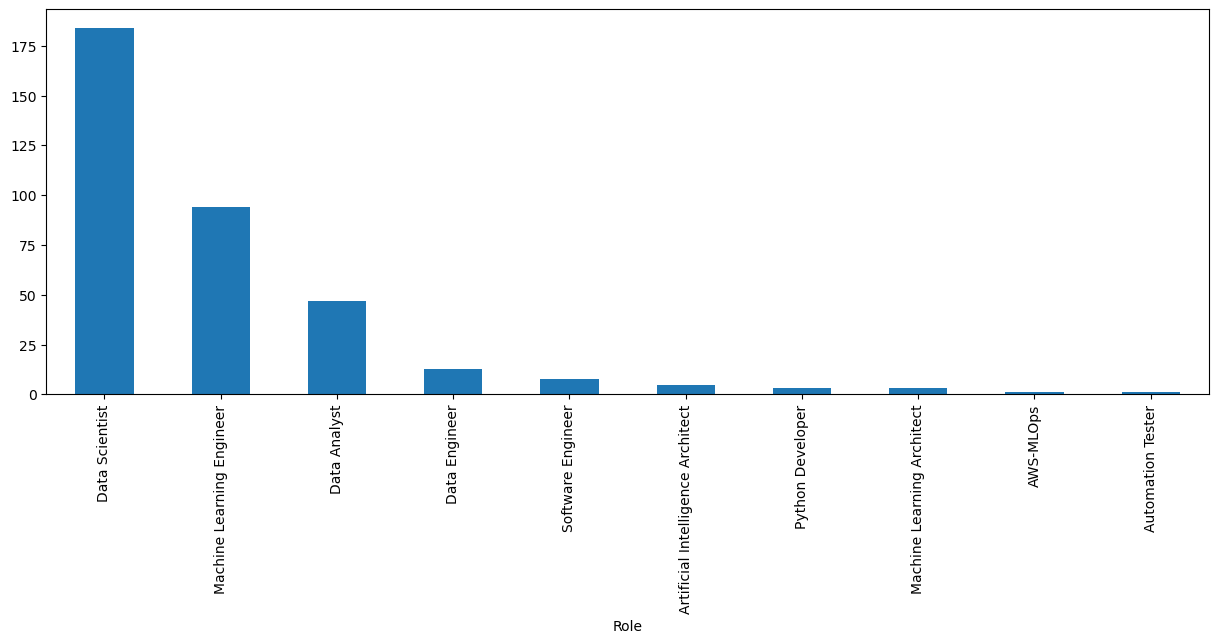

In [58]:
#Segment Extration
f,ax=plt.subplots(figsize=(15,5))
df['Role'].value_counts().head(10).plot(kind = 'bar')

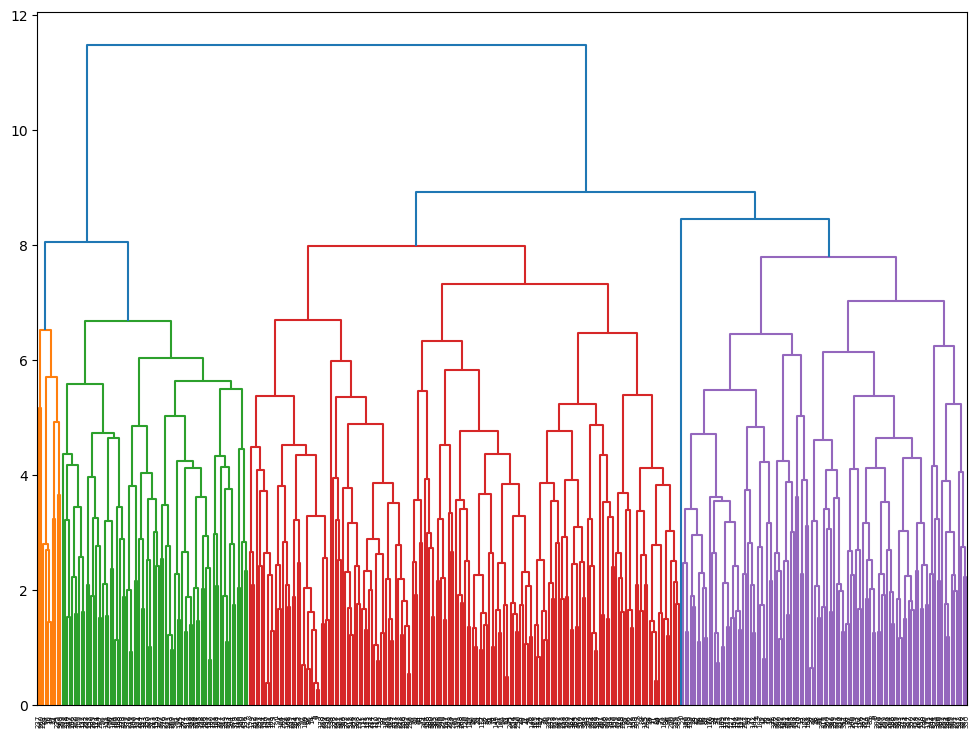

In [59]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

linked = linkage(data2, 'complete')

#labelList = range(1, 11)

plt.figure(figsize=(12, 9))
dendrogram(linked, orientation='top')
plt.show()

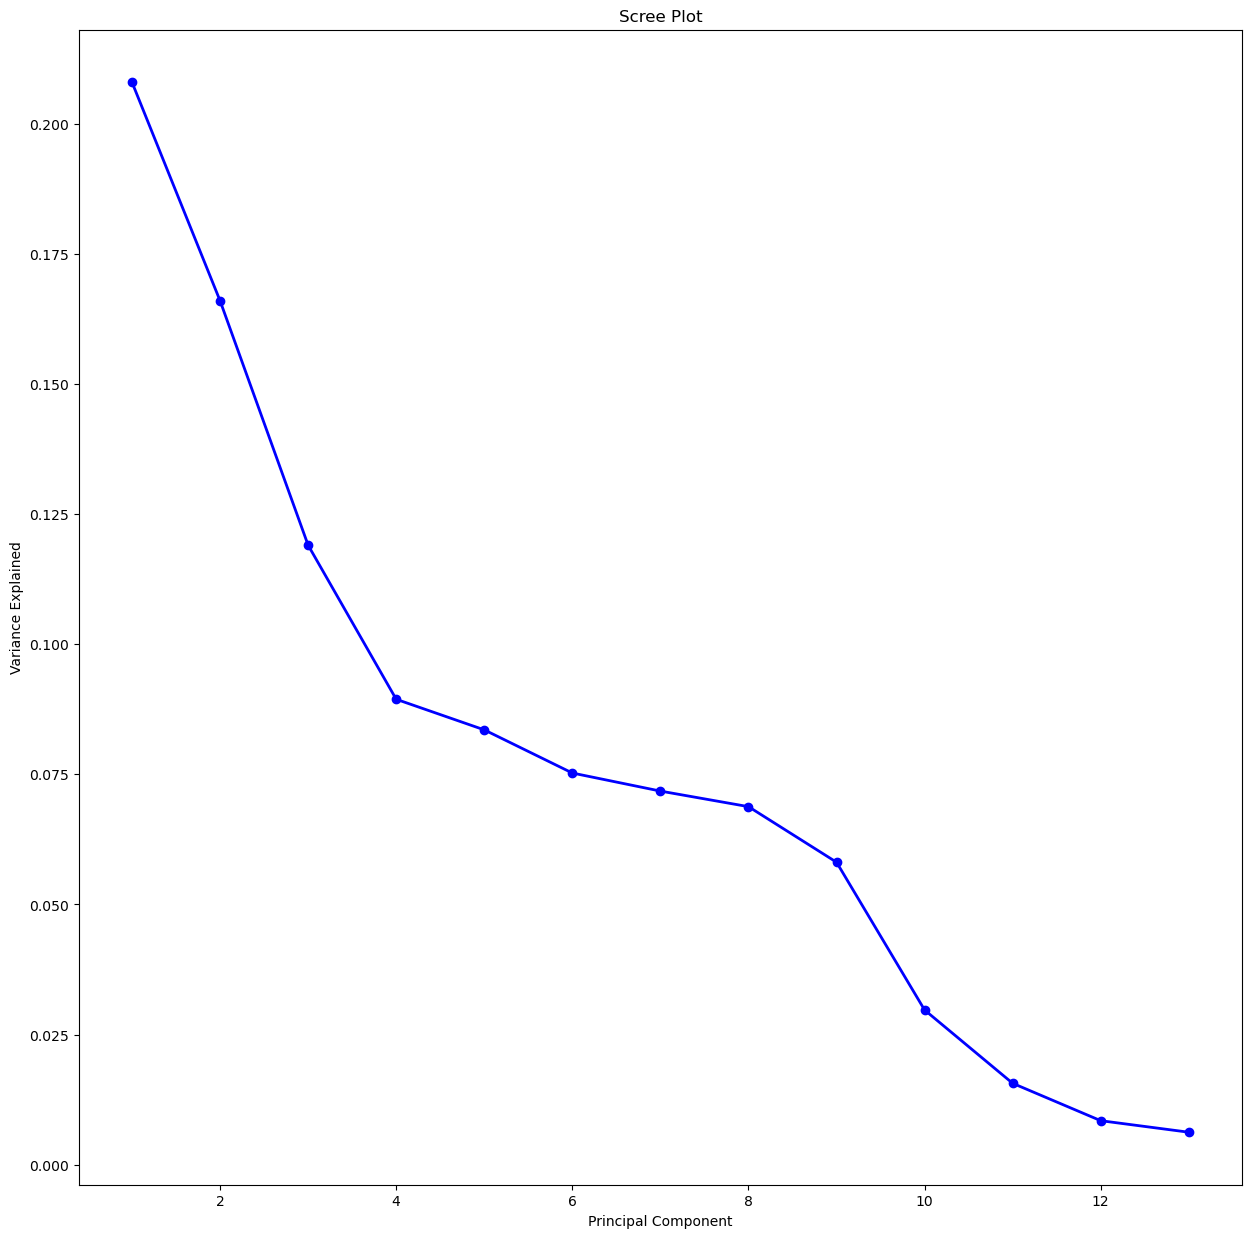

In [60]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

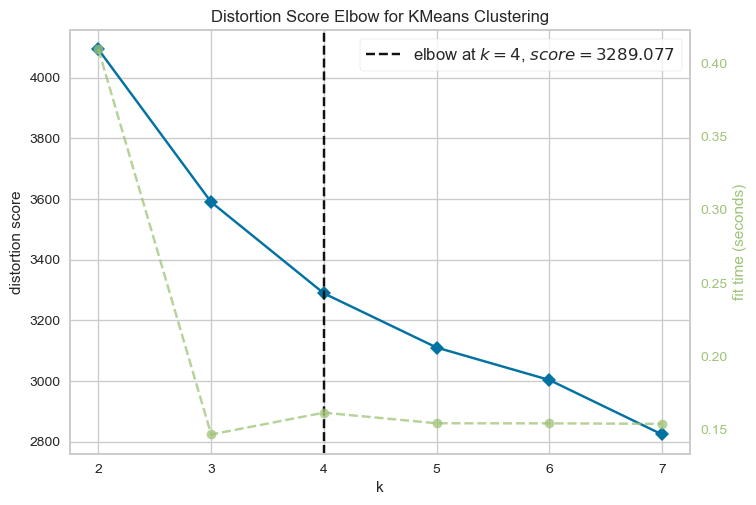

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [61]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,8))
visualizer.fit(t)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [62]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0).fit(t)
df['cluster_num'] = kmeans.labels_ #adding to df
print (kmeans.labels_) #Label assigned for each data point
print (kmeans.inertia_) #gives within-cluster sum of squares.
print(kmeans.n_iter_) #number of iterations that k-means algorithm runs to get a minimum within-cluster sum of squares
print(kmeans.cluster_centers_) #Location of the centroids on each cluster.

[0 0 2 0 0 0 0 0 1 1 1 1 1 0 0 1 1 2 1 1 1 1 0 0 0 1 1 2 0 0 2 0 1 1 2 2 1
 1 2 0 2 1 0 0 1 1 1 2 1 1 1 1 3 1 1 0 2 2 0 1 1 1 1 2 0 1 3 0 0 0 1 2 0 1
 1 2 2 0 1 0 2 0 0 0 2 1 0 0 2 1 1 0 0 1 1 1 2 0 1 3 0 1 0 1 0 0 3 1 3 3 1
 2 1 2 3 2 1 1 3 0 1 3 0 1 3 3 2 0 1 0 3 3 3 1 1 1 3 1 3 0 0 0 0 3 0 1 0 1
 1 2 2 3 2 3 0 2 1 3 1 2 3 0 2 0 3 2 3 3 0 0 3 1 3 0 2 0 0 0 0 0 3 1 1 1 2
 0 1 2 3 1 0 1 0 3 0 0 3 3 3 1 2 1 2 0 1 1 0 3 1 1 1 1 0 3 1 2 3 1 1 2 0 1
 1 2 3 3 1 3 1 2 1 2 3 0 0 0 0 3 3 2 3 0 2 3 2 1 3 1 1 1 1 0 1 1 1 1 1 3 1
 1 3 2 0 3 0 0 3 1 1 3 0 3 1 3 3 1 0 1 1 3 0 1 1 3 1 3 3 0 1 2 0 0 1 0 2 1
 1 0 2 3 3 3 0 2 3 1 2 3 2 2 1 3 1 3 3 1 3 3 3 3 3 3 0 0 1 0 1 1 3 0 0 1 3
 1 0 2 1 3 1 2 0 2 1 3 3 3 2 3 1 3 1 1 1 0 0 1 1 1 0 3 1 1 0 1 2 1 2 3 0 1
 0 1 1 1 1 2 3 1 2 2 1 2 2 1 1 1 2 1]
3280.062846362227
16
[[-5.54492618e-01  1.58917774e+00 -3.56930434e-01 -5.33661579e-01
  -3.78036334e-02  4.79572506e-01 -3.43718285e-01 -5.37394417e-01
   1.75918101e-02  1.41509629e-03  5.62426636e-03 -1.557801

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



In [63]:
#To see each cluster size
from collections import Counter
Counter(kmeans.labels_)

Counter({1: 144, 0: 100, 3: 81, 2: 63})

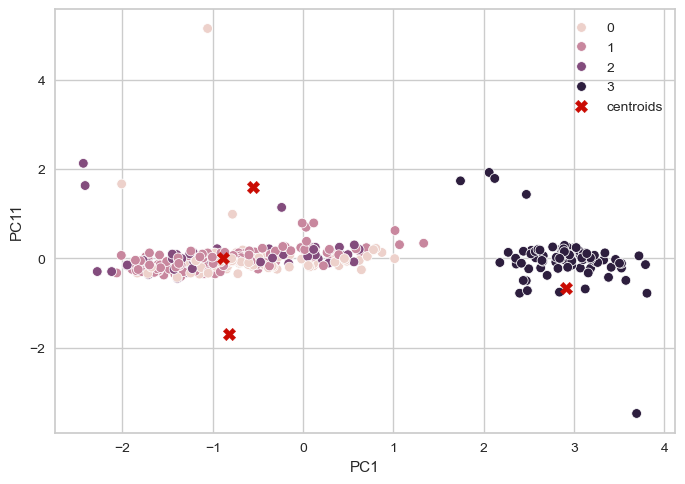

In [64]:
#Visulazing clusters
sns.scatterplot(data=data2, x="PC1", y="PC11", hue=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker="X", c="r", s=80, label="centroids")
plt.legend()
plt.show()


In [65]:
X=data2[['PC1', 'PC2','PC3','PC4','Pc5','PC6', 'PC7','PC8','PC12','PC13']]
y=df['avg_pay']

In [66]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.4, random_state=101)

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
lm=LinearRegression().fit(X_train,y_train)

In [70]:
print(lm.intercept_)

1061547.4595251807


In [71]:
lm.coef_

array([   9626.51826713,  471271.0772673 , -291882.01535108,
        -16530.07700699,  -54650.4540447 ,  116017.49124538,
        -94883.5073091 ,  -90638.85809046,   38913.1111121 ,
        529075.95178603])

In [72]:
X_train.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'Pc5', 'PC6', 'PC7', 'PC8', 'PC12', 'PC13'], dtype='object')

In [73]:
cdf=pd.DataFrame(lm.coef_, X.columns, columns=['Coeff'])

In [74]:
cdf

,Coeff
PC1,9626.518267
PC2,471271.077267
PC3,-291882.015351
PC4,-16530.077007
Pc5,-54650.454045
PC6,116017.491245
PC7,-94883.507309
PC8,-90638.858090
PC12,38913.111112
PC13,529075.951786


In [75]:
predictions=lm.predict(X_test)
predictions

array([ -76115.8640707 , 2343187.72044151, 1714129.20221107,
       1070843.19670328,  561204.18441462,  766547.93579967,
       1278988.52988264,  521459.64048182, 1270161.98487373,
        732576.03460343, -225796.82851283,  954870.84733086,
       2320089.43852728, 1515043.306105  ,  629202.23366666,
        919074.15185108, 2001246.9111822 ,  765278.85328615,
        -43635.16409912, 2530937.25610314, 1410113.27761786,
         31328.30446167, 2037152.01091151, 1773556.63531565,
       2700796.86034409, 1884331.17755788, 1480712.45804912,
        483089.77044797, 1461793.925495  , 2040528.40046837,
       1019556.40130621,  831880.25026849, 1522931.59187781,
       1839357.6120214 , 1825818.29895636, 1114406.58719623,
       1754967.65035203, 1792866.63735993,  713871.2691839 ,
       1916719.54679675, 2022280.7514739 ,  986253.48768845,
         52076.08567886,  498699.06887001, 1086209.28290055,
       1265254.50306192,  744812.89741403,  492413.95041649,
        607185.61070953,

In [76]:
y_test

38           0.0
178    2550000.0
160    1600000.0
98      850000.0
117     700000.0
         ...    
188    1400000.0
170          0.0
20      575000.0
119    1500000.0
167    1500000.0
Name: avg_pay, Length: 156, dtype: float64

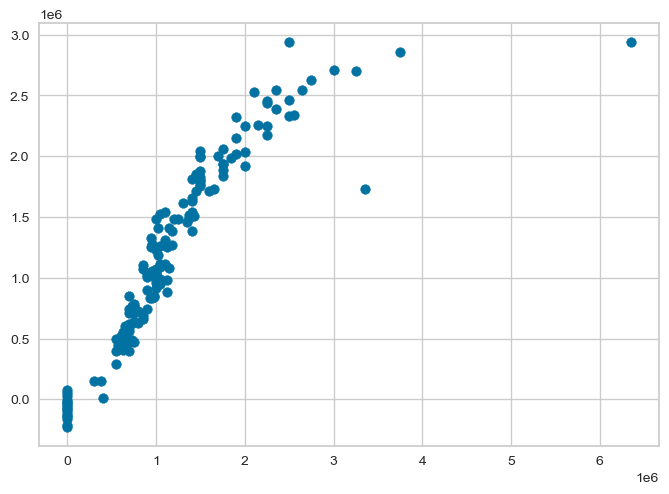

In [77]:
plt.scatter(y_test, predictions)

C:\Users\bhara\AppData\Local\Temp\ipykernel_10868\3491059997.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='avg_pay', ylabel='Density'>

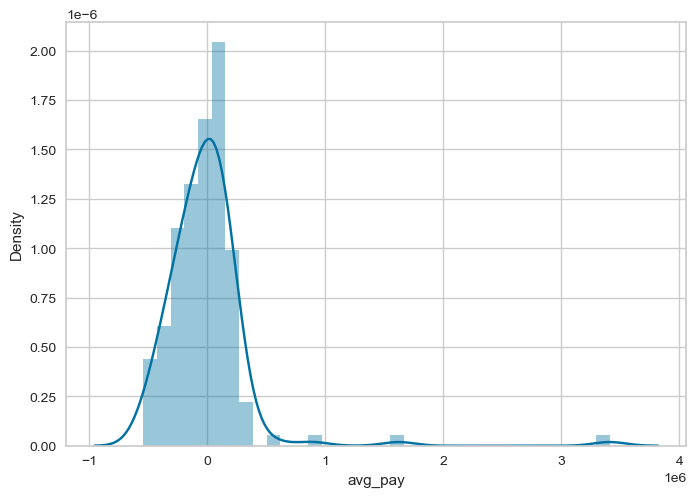

In [78]:
sns.distplot((y_test-predictions))

In [79]:
from sklearn import metrics
print('MAE:',metrics.mean_absolute_error(y_test,predictions))
print('MSE:',metrics.mean_squared_error(y_test,predictions))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,predictions)))

MAE: 204816.81313769365
MSE: 140633816957.67978
RMSE: 375011.7557593092


In [80]:
metrics.mean_absolute_error(y_test,predictions)

204816.81313769365

In [81]:
metrics.mean_squared_error(y_test,predictions)

140633816957.67978

In [82]:
np.sqrt(metrics.mean_squared_error(y_test,predictions))

375011.7557593092

In [84]:
metrics.r2_score(y_test,predictions)

0.7990187586392052